In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv(r'C:\Users\PRUTHVI\OneDrive\Desktop\EL Matador AI\data\ufc_clean.csv')

In [4]:
y = df['red_win']

columns_to_drop = list(df.select_dtypes(include=['object']).columns)
columns_to_drop.append('red_win')
print(columns_to_drop)
X = df.drop(columns=columns_to_drop)

['R_fighter', 'B_fighter', 'date', 'country', 'weight_class', 'gender', 'better_rank', 'finish', 'finish_details', 'finish_round_time', 'red_win']


In [5]:
print(X.shape)
print(y.shape)

(7177, 111)
(7177,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print('Training Samples:',X_train.shape[0])
print('Testing Samples',X_test.shape[0])

Training Samples: 5741
Testing Samples 1436


In [7]:
model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)
print('Model Training complete')

Model Training complete


In [8]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test,predictions)
print(f'Initial baseline accuracy {accuracy: .2%}')

print('DEtailed Classification Report: ')
print(classification_report(y_test,predictions))

Initial baseline accuracy  65.74%
DEtailed Classification Report: 
              precision    recall  f1-score   support

           0       0.60      0.53      0.56       598
           1       0.69      0.75      0.72       838

    accuracy                           0.66      1436
   macro avg       0.65      0.64      0.64      1436
weighted avg       0.65      0.66      0.65      1436



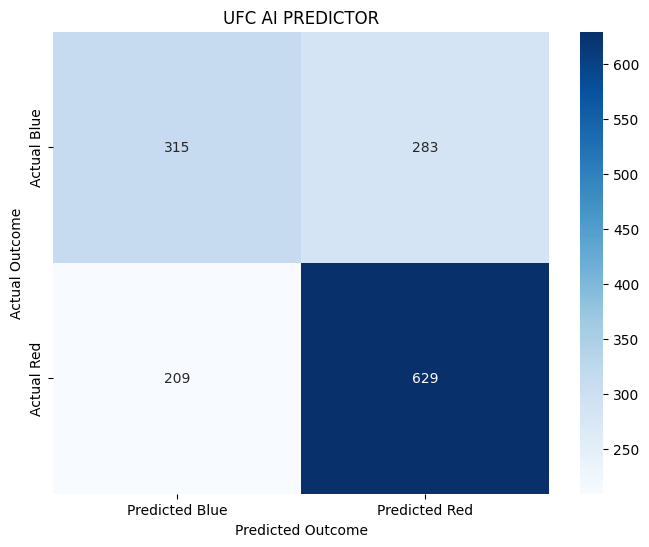

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Predicted Blue','Predicted Red'],
            yticklabels=['Actual Blue','Actual Red'])
plt.title('UFC AI PREDICTOR')
plt.xlabel('Predicted Outcome')
plt.ylabel('Actual Outcome')
plt.show()


below we can see that our model is mostly dependent on the odds set by the big dawgs , so our model is not really that impressive so now we will try to create a model without the odds , just purely on the physical stats

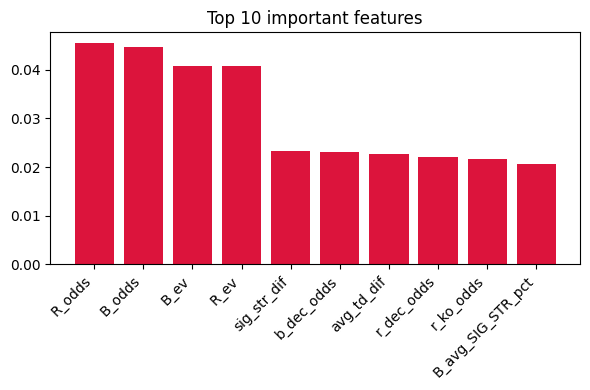

In [10]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(6,4))
plt.title('Top 10 important features')
plt.bar(range(10),importances[indices[:10]],color = 'crimson',align = 'center')
plt.xticks(range(10),X.columns[indices[:10]],rotation = 45 , ha = 'right')
plt.tight_layout()
plt.show()

see now even without the bets and ev we are getting a 61% accuracy thats a huge success 

In [15]:
columns_to_drop_no_odds = list(df.select_dtypes(include=['object']).columns)
columns_to_drop_no_odds.append('red_win')

odds_ev_col = [col for col in df.columns if 'odds' in col.lower() or 'ev' in col.lower() or 'profit' in col.lower()]
columns_to_drop_no_odds.extend(odds_ev_col)

X_no_odds = df.drop(columns=columns_to_drop_no_odds)

X_train_no,X_test_no,y_train_no,y_test_no = train_test_split(X_no_odds,y,test_size=0.2,random_state=42)

pure_model = RandomForestClassifier(n_estimators=100,random_state=42)
pure_model.fit(X_train_no,y_train_no)

pure_pred = pure_model.predict(X_test_no)

pure_accuracy = accuracy_score(y_test_no,pure_pred)
print('THis is the pure accuracy of the model: ',pure_accuracy*100)

THis is the pure accuracy of the model:  61.14206128133704
